In [1]:
from pathlib import Path
import json
import time
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

from IPython.display import display, Markdown
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    precision_recall_curve,
)
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier, Pool

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

BASE_DIR = Path.cwd()
PROJECT_ROOT = BASE_DIR.parent if BASE_DIR.name == 'noteboods' else BASE_DIR
DATA_DIR = PROJECT_ROOT / 'data'
ARTIFACT_DIR = PROJECT_ROOT / 'artifacts' / 'modeling'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
METADATA_PATH = ARTIFACT_DIR / 'metadata.json'

MODEL_SLUGS = {
    'Logistic Regression': 'logistic_regression',
    'Random Forest': 'random_forest',
    'LightGBM': 'lightgbm',
    'XGBoost': 'xgboost',
    'CatBoost': 'catboost',
}
MODEL_FILE_NAMES = {
    'Logistic Regression': 'best_logistic_model.joblib',
    'Random Forest': 'best_random_forest_model.joblib',
    'LightGBM': 'best_lightgbm_model.joblib',
    'XGBoost': 'best_xgboost_model.joblib',
    'CatBoost': 'best_catboost_model.cbm',
}

# Predictive Modeling

This page presents the predictive modeling stage of the project: estimating whether a reported Chicago crime incident results in an arrest. The modeling design is intentionally forward-looking, using **out-of-time validation** rather than random splitting, and it treats **PR-AUC** as the primary headline metric because arrest outcomes are relatively rare.

The structure of the page follows the logic of the modeling workflow. It starts with the prediction objective and evaluation protocol, then compares the main model families, and finally closes with robustness checks, feature ablation, and SHAP-based interpretation for the best final model.

## 1. Objective and Modeling Framing

This notebook predicts whether a reported Chicago crime incident results in an arrest. The modeling goal is **out-of-time generalization** rather than fitting the arrest rate of the same calendar year.

The evaluation design is intentionally locked before model fitting. `Year` is **not** used as a predictor. Instead, `Year` is reserved for temporal splitting, rolling validation, and stratified sampling. Hyperparameters are chosen by **validation PR-AUC**, which is the most appropriate primary metric because arrest outcomes are relatively rare and the data are therefore imbalanced. Threshold selection is separated from hyperparameter tuning: each final model uses the threshold chosen on the validation window, and that threshold is then carried unchanged into the test evaluation.


In [2]:
usecols = [
    'Arrest', 'Year', 'Month', 'DayOfWeek', 'Hour',
    'Primary Type', 'Location Description', 'Domestic', 'Community Area'
]

df = pd.read_csv(DATA_DIR / 'df.csv', usecols=usecols)
TARGET = 'Arrest'
YEAR_COL = 'Year'
BASE_FEATURES = ['Month', 'DayOfWeek', 'Hour', 'Primary Type', 'Location Description', 'Domestic', 'Community Area']
CAT_FEATURES = ['Primary Type', 'Location Description', 'Community Area']
TRAIN_YEARS = list(range(2016, 2022))
VAL_YEARS = [2022, 2023]
TEST_YEARS = [2024, 2025]
ROLLING_HOLDOUT_YEARS = [2020, 2021, 2022, 2023, 2024, 2025]
TUNING_ROWS = 200_000
FINAL_TRAIN_ROWS = 800_000
SHAP_SAMPLE_ROWS = 10_000
RANDOM_STATE = 42
TIME_BUDGET_SECONDS = 600
TRIAL_BUDGETS = {
    'Logistic Regression': {'n_trials': 12, 'timeout': 240},
    'Random Forest': {'n_trials': 12, 'timeout': 300},
    'LightGBM': {'n_trials': 24, 'timeout': 420},
    'XGBoost': {'n_trials': 24, 'timeout': 420},
    'CatBoost': {'n_trials': 24, 'timeout': 420},
}
MODEL_SAMPLE_FALLBACKS = {
    'Logistic Regression': [800_000, 500_000],
    'Random Forest': [800_000, 500_000, 300_000],
    'LightGBM': [800_000, 500_000],
    'XGBoost': [800_000, 500_000],
    'CatBoost': [800_000, 500_000, 300_000],
}

for col in ['Month', 'DayOfWeek', 'Hour', 'Community Area']:
    df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int32')
df[TARGET] = df[TARGET].astype(int)
df['Domestic'] = df['Domestic'].astype(int)
df['Primary Type'] = df['Primary Type'].astype(str)
df['Location Description'] = df['Location Description'].astype(str)
df = df.dropna(subset=BASE_FEATURES + [TARGET, YEAR_COL]).copy()
df['Community Area'] = df['Community Area'].astype(int).astype(str)

train_full = df[df[YEAR_COL].isin(TRAIN_YEARS)].copy()
val_full = df[df[YEAR_COL].isin(VAL_YEARS)].copy()
test_full = df[df[YEAR_COL].isin(TEST_YEARS)].copy()
print(f'Train rows (2016-2021): {len(train_full):,}')
print(f'Validation rows (2022-2023): {len(val_full):,}')
print(f'Test rows (2024-2025): {len(test_full):,}')

Train rows (2016-2021): 1,492,382
Validation rows (2022-2023): 503,295
Test rows (2024-2025): 495,991


## 2. Data Preparation and Evaluation Protocol

The modeling sample is defined once and then reused throughout the notebook. The final analytic dataset includes complete cases for the selected predictors and target, with `Community Area` retained as a categorical spatial variable. The time split follows a genuinely forward-looking design: the training window covers 2016-2021, validation covers 2022-2023, and the final test window covers 2024-2025.

This structure matters because arrest patterns shift over time. A random split would overstate model performance by mixing older and newer reporting environments. The current design therefore asks a more policy-relevant question: whether relationships learned from earlier years remain useful for later years.

In [3]:
def stratified_sample(data, target_rows, strata_cols=(YEAR_COL, TARGET), random_state=RANDOM_STATE):
    if len(data) <= target_rows:
        return data.copy().reset_index(drop=True)
    fraction = target_rows / len(data)
    pieces = []
    for _, group in data.groupby(list(strata_cols), observed=True, sort=False):
        take = max(1, int(round(len(group) * fraction)))
        take = min(take, len(group))
        pieces.append(group.sample(n=take, random_state=random_state))
    sampled = pd.concat(pieces).sort_index()
    if len(sampled) > target_rows:
        sampled = sampled.sample(n=target_rows, random_state=random_state)
    elif len(sampled) < target_rows:
        remainder = data.drop(sampled.index, errors='ignore')
        if not remainder.empty:
            extra = min(target_rows - len(sampled), len(remainder))
            sampled = pd.concat([sampled, remainder.sample(n=extra, random_state=random_state)])
    return sampled.reset_index(drop=True)


def choose_threshold(y_true, scores):
    precision, recall, thresholds = precision_recall_curve(y_true, scores)
    if len(thresholds) == 0:
        return 0.5
    f1_values = 2 * precision[:-1] * recall[:-1] / np.clip(precision[:-1] + recall[:-1], 1e-9, None)
    return float(thresholds[int(np.nanargmax(f1_values))])


def evaluate_at_threshold(y_true, scores, threshold, model_name, split_name, training_rows, imbalance_setting):
    preds = (scores >= threshold).astype(int)
    return {
        'Model': model_name,
        'Split': split_name,
        'Threshold': float(threshold),
        'Training Rows': int(training_rows),
        'Imbalance Handling': imbalance_setting,
        'ROC-AUC': roc_auc_score(y_true, scores),
        'PR-AUC': average_precision_score(y_true, scores),
        'F1': f1_score(y_true, preds, zero_division=0),
        'Precision': precision_score(y_true, preds, zero_division=0),
        'Recall': recall_score(y_true, preds, zero_division=0),
    }


def prepare_typed_frame(frame, features):
    out = frame[features].copy()
    for col in ['Month', 'DayOfWeek', 'Hour']:
        if col in out:
            out[col] = out[col].astype(int)
    if 'Domestic' in out:
        out['Domestic'] = out['Domestic'].astype(int)
    if 'Primary Type' in out:
        out['Primary Type'] = out['Primary Type'].astype(str)
    if 'Location Description' in out:
        out['Location Description'] = out['Location Description'].astype(str)
    if 'Community Area' in out:
        out['Community Area'] = out['Community Area'].astype(str)
    return out


def prepare_lgb_frame(frame, features):
    out = prepare_typed_frame(frame, features)
    for col in CAT_FEATURES:
        if col in out:
            out[col] = out[col].astype('category')
    return out


def get_category_maps(reference_frame):
    maps = {}
    for col in ['Primary Type', 'Location Description']:
        values = sorted(reference_frame[col].astype(str).unique())
        maps[col] = {value: idx for idx, value in enumerate(values)}
    return maps


def prepare_xgb_frame(frame, features, category_maps):
    out = prepare_typed_frame(frame, features)
    for col, mapping in category_maps.items():
        if col in out:
            out[col] = out[col].map(mapping).fillna(-1).astype(int)
    if 'Community Area' in out:
        out['Community Area'] = out['Community Area'].astype(int)
    return out


def prepare_cat_frame(frame, features):
    return prepare_typed_frame(frame, features)


def sanitize_logistic_params(params):
    return {'C': float(params['C']), 'class_weight': None if params['class_weight'] == 'None' else params['class_weight']}


def sanitize_rf_params(params):
    return {
        'n_estimators': int(params['n_estimators']),
        'max_depth': None if params.get('use_none_max_depth', False) else int(params['max_depth']),
        'min_samples_leaf': int(params['min_samples_leaf']),
        'max_features': params['max_features'] if params['max_features'] == 'sqrt' else float(params['max_features']),
        'class_weight': None if params['class_weight'] == 'None' else params['class_weight'],
    }


def sanitize_lgb_params(params):
    return {
        'num_leaves': int(params['num_leaves']),
        'min_child_samples': int(params['min_child_samples']),
        'learning_rate': float(params['learning_rate']),
        'n_estimators': int(params['n_estimators']),
        'subsample': float(params['subsample']),
        'colsample_bytree': float(params['colsample_bytree']),
        'reg_lambda': float(params['reg_lambda']),
        'scale_pos_weight': float(params['scale_pos_weight']),
    }


def sanitize_xgb_params(params):
    return {
        'max_depth': int(params['max_depth']),
        'min_child_weight': int(params['min_child_weight']),
        'learning_rate': float(params['learning_rate']),
        'n_estimators': int(params['n_estimators']),
        'subsample': float(params['subsample']),
        'colsample_bytree': float(params['colsample_bytree']),
        'gamma': float(params['gamma']),
        'reg_lambda': float(params['reg_lambda']),
        'scale_pos_weight': float(params['scale_pos_weight']),
    }


def sanitize_cat_params(params):
    return {
        'depth': int(params['depth']),
        'learning_rate': float(params['learning_rate']),
        'iterations': int(params['iterations']),
        'l2_leaf_reg': float(params['l2_leaf_reg']),
        'auto_class_weights': None if params['auto_class_weights'] == 'None' else params['auto_class_weights'],
    }


def fit_final_with_fallback(model_name, build_fn, params, train_data, fit_fn, validation_payload):
    attempts = []
    artifact = None
    for rows in MODEL_SAMPLE_FALLBACKS[model_name]:
        sample_rows = min(rows, len(train_data))
        sample = stratified_sample(train_data, sample_rows)
        start = time.time()
        model = build_fn(params)
        fit_fn(model, sample, validation_payload)
        elapsed = time.time() - start
        attempts.append({'Training Rows': len(sample), 'Seconds': elapsed})
        artifact = {'model': model, 'training_rows': len(sample), 'seconds': elapsed}
        if elapsed <= TIME_BUDGET_SECONDS or rows == MODEL_SAMPLE_FALLBACKS[model_name][-1]:
            break
    return artifact, pd.DataFrame(attempts)


def load_metadata():
    if METADATA_PATH.exists():
        return json.loads(METADATA_PATH.read_text())
    return {}


def save_metadata(metadata):
    METADATA_PATH.write_text(json.dumps(metadata, indent=2))


def update_root_metadata(payload):
    metadata = load_metadata()
    metadata.update(payload)
    save_metadata(metadata)
    return metadata


def update_model_metadata(model_name, payload):
    metadata = load_metadata()
    metadata.setdefault('models', {})[model_name] = payload
    save_metadata(metadata)
    return metadata


def update_section_metadata(section_name, payload):
    metadata = load_metadata()
    metadata.setdefault('sections', {})[section_name] = payload
    save_metadata(metadata)
    return metadata


def model_artifact_path(model_name):
    return ARTIFACT_DIR / MODEL_FILE_NAMES[model_name]


def frame_path(name):
    return ARTIFACT_DIR / name


def save_frame(df_obj, path):
    df_obj.to_csv(path, index=False)


def load_frame(path):
    return pd.read_csv(path)


def save_model_artifact(model_name, model):
    path = model_artifact_path(model_name)
    if model_name == 'CatBoost':
        model.save_model(path)
    else:
        joblib.dump(model, path)


def load_model_artifact(model_name):
    path = model_artifact_path(model_name)
    if model_name == 'CatBoost':
        model = CatBoostClassifier()
        model.load_model(path)
        return model
    return joblib.load(path)


def cache_ready(model_name, extra_paths=None):
    extra_paths = extra_paths or []
    required = [model_artifact_path(model_name)] + [Path(p) for p in extra_paths]
    return all(path.exists() for path in required)


category_maps = get_category_maps(df)
tuning_sample = stratified_sample(train_full, TUNING_ROWS)
refit_sample_preview = stratified_sample(train_full, FINAL_TRAIN_ROWS)

split_summary = pd.DataFrame([
    {'Split': 'Train (full)', 'Years': '2016-2021', 'Rows': len(train_full), 'Arrest Rate': train_full[TARGET].mean()},
    {'Split': 'Train (tuning sample)', 'Years': '2016-2021', 'Rows': len(tuning_sample), 'Arrest Rate': tuning_sample[TARGET].mean()},
    {'Split': 'Train (final target)', 'Years': '2016-2021', 'Rows': len(refit_sample_preview), 'Arrest Rate': refit_sample_preview[TARGET].mean()},
    {'Split': 'Validation', 'Years': '2022-2023', 'Rows': len(val_full), 'Arrest Rate': val_full[TARGET].mean()},
    {'Split': 'Test', 'Years': '2024-2025', 'Rows': len(test_full), 'Arrest Rate': test_full[TARGET].mean()},
])
split_summary['Rows'] = split_summary['Rows'].map(lambda x: f'{x:,}')
split_summary['Arrest Rate'] = split_summary['Arrest Rate'].map(lambda x: f'{x:.2%}')
display(split_summary)
display(pd.DataFrame({'Main Model Features': BASE_FEATURES}))

base_scale_pos_weight = (1 - train_full[TARGET].mean()) / train_full[TARGET].mean()
X_tune_base = prepare_typed_frame(tuning_sample, BASE_FEATURES)
y_tune = tuning_sample[TARGET].astype(int)
X_val_base = prepare_typed_frame(val_full, BASE_FEATURES)
y_val = val_full[TARGET].astype(int)
X_test_base = prepare_typed_frame(test_full, BASE_FEATURES)
y_test = test_full[TARGET].astype(int)
X_val_lgb = prepare_lgb_frame(val_full, BASE_FEATURES)
X_test_lgb = prepare_lgb_frame(test_full, BASE_FEATURES)
X_val_xgb = prepare_xgb_frame(val_full, BASE_FEATURES, category_maps)
X_test_xgb = prepare_xgb_frame(test_full, BASE_FEATURES, category_maps)
X_val_cat = prepare_cat_frame(val_full, BASE_FEATURES)
X_test_cat = prepare_cat_frame(test_full, BASE_FEATURES)
cat_feature_indices = [BASE_FEATURES.index(col) for col in CAT_FEATURES]

metadata = update_root_metadata({
    'artifact_version': 1,
    'feature_config': {
        'base_features': BASE_FEATURES,
        'cat_features': CAT_FEATURES,
        'cat_feature_indices': cat_feature_indices,
        'category_maps': category_maps,
    },
    'split_config': {
        'train_years': TRAIN_YEARS,
        'validation_years': VAL_YEARS,
        'test_years': TEST_YEARS,
        'tuning_rows': TUNING_ROWS,
        'final_train_rows': FINAL_TRAIN_ROWS,
        'shap_sample_rows': SHAP_SAMPLE_ROWS,
        'random_state': RANDOM_STATE,
    },
})

,Split,Years,Rows,Arrest Rate
0,Train (full),2016-2021,"1,492,382",18.55%
1,Train (tuning sample),2016-2021,"200,000",18.55%
2,Train (final target),2016-2021,"800,000",18.55%
3,Validation,2022-2023,"503,295",12.00%
4,Test,2024-2025,"495,991",14.86%


,Main Model Features
0,Month
1,DayOfWeek
2,Hour
3,Primary Type
4,Location Description
5,Domestic
6,Community Area


## 3. Class Imbalance Strategy

The overall arrest rate is low enough that class imbalance must be treated as a central modeling issue rather than a minor adjustment. For that reason, **PR-AUC** is the primary selection metric throughout the notebook. ROC-AUC is still reported because it remains informative about ranking quality, but PR-AUC is more sensitive to performance on the minority class and therefore better aligned with the substantive prediction task.

Imbalance handling and threshold choice are also separated on purpose. Class weighting or related settings affect how the model learns, whereas the threshold determines how predicted probabilities are converted into class labels. Keeping those two decisions separate makes the final comparisons more interpretable.

A small implementation note is worth making explicit: some model-specific training interfaces still use AUC or a default ranking-oriented validation hook for early stopping. That does not change the project decision rule. Final model selection, comparison, and interpretation are all anchored to validation and test **PR-AUC**.


## 4. Logistic Regression

Logistic Regression serves as the linear baseline. It provides a transparent benchmark for whether the main signal in the data can be captured through additive effects after categorical encoding.

The goal in this section is not to make the linear model look competitive with the boosted ensembles at all costs. It is to establish a clear baseline for how much predictive value is already available before introducing richer non-linear structure.


In [4]:
def build_logistic_model(params):
    preprocessor = ColumnTransformer([
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore')),
        ]), ['Month', 'DayOfWeek', 'Hour', 'Primary Type', 'Location Description', 'Community Area']),
        ('bin', Pipeline([('imputer', SimpleImputer(strategy='most_frequent'))]), ['Domestic']),
    ])
    model = LogisticRegression(
        C=params['C'],
        class_weight=params['class_weight'],
        max_iter=600,
        solver='saga',
        penalty='l2',
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )
    return Pipeline([('preprocess', preprocessor), ('model', model)])


def logistic_objective(trial):
    params = sanitize_logistic_params({
        'C': trial.suggest_float('C', 1e-3, 10.0, log=True),
        'class_weight': trial.suggest_categorical('class_weight', ['None', 'balanced']),
    })
    model = build_logistic_model(params)
    model.fit(X_tune_base, y_tune)
    val_scores = model.predict_proba(X_val_base)[:, 1]
    pr_auc = average_precision_score(y_val, val_scores)
    trial.set_user_attr('roc_auc', roc_auc_score(y_val, val_scores))
    threshold = choose_threshold(y_val, val_scores)
    trial.set_user_attr('f1', f1_score(y_val, (val_scores >= threshold).astype(int), zero_division=0))
    return pr_auc


logistic_tuning_path = frame_path('logistic_regression_tuning.csv')
logistic_results_path = frame_path('logistic_regression_results.csv')
logistic_attempts_path = frame_path('logistic_regression_attempts.csv')
logistic_meta = load_metadata().get('models', {}).get('Logistic Regression', {})

if cache_ready('Logistic Regression', [logistic_tuning_path, logistic_results_path, logistic_attempts_path]) and logistic_meta:
    best_logistic_model = load_model_artifact('Logistic Regression')
    logistic_tuning = load_frame(logistic_tuning_path)
    logistic_results = load_frame(logistic_results_path)
    logistic_attempts = load_frame(logistic_attempts_path)
    best_logistic_params = logistic_meta['best_params']
    logistic_training_rows = int(logistic_meta['training_rows'])
    logistic_threshold = float(logistic_meta['threshold'])
else:
    logistic_study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    logistic_study.optimize(logistic_objective, **TRIAL_BUDGETS['Logistic Regression'])
    logistic_tuning = pd.DataFrame([
        {
            'trial': t.number,
            'Validation PR-AUC': t.value,
            'Validation ROC-AUC': t.user_attrs.get('roc_auc'),
            'Validation F1': t.user_attrs.get('f1'),
            **t.params,
        }
        for t in logistic_study.trials if t.value is not None
    ]).sort_values(['Validation PR-AUC', 'Validation ROC-AUC', 'Validation F1'], ascending=False)
    best_logistic_params = sanitize_logistic_params(logistic_study.best_trial.params)

    def logistic_fit_fn(model, sample, validation_payload):
        model.fit(prepare_typed_frame(sample, BASE_FEATURES), sample[TARGET].astype(int))

    logistic_artifact, logistic_attempts = fit_final_with_fallback(
        'Logistic Regression',
        build_logistic_model,
        best_logistic_params,
        train_full,
        logistic_fit_fn,
        None,
    )
    best_logistic_model = logistic_artifact['model']
    logistic_training_rows = logistic_artifact['training_rows']
    logistic_val_scores = best_logistic_model.predict_proba(X_val_base)[:, 1]
    logistic_threshold = choose_threshold(y_val, logistic_val_scores)
    logistic_test_scores = best_logistic_model.predict_proba(X_test_base)[:, 1]
    logistic_results = pd.DataFrame([
        evaluate_at_threshold(y_val, logistic_val_scores, logistic_threshold, 'Logistic Regression', 'Validation', logistic_training_rows, f"class_weight={best_logistic_params['class_weight']}"),
        evaluate_at_threshold(y_test, logistic_test_scores, logistic_threshold, 'Logistic Regression', 'Test', logistic_training_rows, f"class_weight={best_logistic_params['class_weight']}"),
    ])

    save_model_artifact('Logistic Regression', best_logistic_model)
    save_frame(logistic_tuning, logistic_tuning_path)
    save_frame(logistic_results, logistic_results_path)
    save_frame(logistic_attempts, logistic_attempts_path)
    metadata = update_model_metadata('Logistic Regression', {
        'best_params': best_logistic_params,
        'threshold': float(logistic_threshold),
        'training_rows': int(logistic_training_rows),
        'model_file': MODEL_FILE_NAMES['Logistic Regression'],
        'tuning_file': logistic_tuning_path.name,
        'results_file': logistic_results_path.name,
        'attempts_file': logistic_attempts_path.name,
    })

tuning_view = logistic_tuning.head(5).copy()
results_view = logistic_results[['Split', 'Threshold', 'Training Rows', 'Imbalance Handling', 'PR-AUC', 'ROC-AUC', 'F1', 'Precision', 'Recall']].copy()

display(tuning_view)
display(results_view)

best_7_row = results_view[results_view['Split'] == 'Test'].iloc[0] if 'Test' in results_view['Split'].values else results_view.iloc[0]
model_note_md = chr(10).join([
    '### Section Takeaway',
    '',
    f"For **Logistic Regression**, the main quantity to track is test PR-AUC rather than any single threshold metric. This model reaches a test PR-AUC of **{best_7_row['PR-AUC']:.3f}** and a test ROC-AUC of **{best_7_row['ROC-AUC']:.3f}**, which places it within the broader baseline-versus-ensemble comparison developed across the page.",
])
display(Markdown(model_note_md))


,trial,Validation PR-AUC,Validation ROC-AUC,Validation F1,C,class_weight
0,11,0.568475,0.836508,0.515769,1.414725,NaN
1,1,0.568421,0.836788,0.515749,0.248104,NaN
2,4,0.568419,0.836401,0.515728,2.136833,NaN
3,10,0.568190,0.836110,0.515738,6.521703,NaN
4,9,0.568033,0.836612,0.516039,0.114009,NaN


,Split,Threshold,Training Rows,Imbalance Handling,PR-AUC,ROC-AUC,F1,Precision,Recall
0,Validation,0.371541,800000,class_weight=None,0.570138,0.837578,0.515432,0.582789,0.462031
1,Test,0.371541,800000,class_weight=None,0.586297,0.832468,0.511854,0.622781,0.434468


### Section Takeaway

For **Logistic Regression**, the main quantity to track is test PR-AUC rather than any single threshold metric. This model reaches a test PR-AUC of **0.586** and a test ROC-AUC of **0.832**, which places it within the broader baseline-versus-ensemble comparison developed across the page.

## 5. Random Forest

Random Forest provides a non-linear ensemble benchmark. It is useful for testing whether interaction structure and threshold effects improve on the linear baseline without relying on boosting-specific optimization.

This section therefore acts as a midpoint comparison: more flexible than Logistic Regression, but methodologically simpler than the boosting models that follow.


In [5]:
def build_rf_model(params):
    preprocessor = ColumnTransformer([
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
        ]), ['Month', 'DayOfWeek', 'Hour', 'Primary Type', 'Location Description', 'Community Area']),
        ('bin', Pipeline([('imputer', SimpleImputer(strategy='most_frequent'))]), ['Domestic']),
    ])
    model = RandomForestClassifier(
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        min_samples_leaf=params['min_samples_leaf'],
        max_features=params['max_features'],
        class_weight=params['class_weight'],
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    return Pipeline([('preprocess', preprocessor), ('model', model)])


def rf_objective(trial):
    use_none = trial.suggest_categorical('use_none_max_depth', [False, True])
    params = sanitize_rf_params({
        'n_estimators': trial.suggest_int('n_estimators', 200, 600, step=100),
        'use_none_max_depth': use_none,
        'max_depth': 12 if use_none else trial.suggest_int('max_depth', 8, 30),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 50, step=5),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 0.3, 0.5, 0.8]),
        'class_weight': trial.suggest_categorical('class_weight', ['None', 'balanced_subsample']),
    })
    model = build_rf_model(params)
    model.fit(X_tune_base, y_tune)
    val_scores = model.predict_proba(X_val_base)[:, 1]
    pr_auc = average_precision_score(y_val, val_scores)
    trial.set_user_attr('roc_auc', roc_auc_score(y_val, val_scores))
    threshold = choose_threshold(y_val, val_scores)
    trial.set_user_attr('f1', f1_score(y_val, (val_scores >= threshold).astype(int), zero_division=0))
    return pr_auc


rf_tuning_path = frame_path('random_forest_tuning.csv')
rf_results_path = frame_path('random_forest_results.csv')
rf_attempts_path = frame_path('random_forest_attempts.csv')
rf_meta = load_metadata().get('models', {}).get('Random Forest', {})

if cache_ready('Random Forest', [rf_tuning_path, rf_results_path, rf_attempts_path]) and rf_meta:
    best_rf_model = load_model_artifact('Random Forest')
    rf_tuning = load_frame(rf_tuning_path)
    rf_results = load_frame(rf_results_path)
    rf_attempts = load_frame(rf_attempts_path)
    best_rf_params = rf_meta['best_params']
    rf_training_rows = int(rf_meta['training_rows'])
    rf_threshold = float(rf_meta['threshold'])
else:
    rf_study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    rf_study.optimize(rf_objective, **TRIAL_BUDGETS['Random Forest'])
    rf_tuning = pd.DataFrame([
        {
            'trial': t.number,
            'Validation PR-AUC': t.value,
            'Validation ROC-AUC': t.user_attrs.get('roc_auc'),
            'Validation F1': t.user_attrs.get('f1'),
            **t.params,
        }
        for t in rf_study.trials if t.value is not None
    ]).sort_values(['Validation PR-AUC', 'Validation ROC-AUC', 'Validation F1'], ascending=False)
    best_rf_params = sanitize_rf_params(rf_study.best_trial.params)

    def rf_fit_fn(model, sample, validation_payload):
        model.fit(prepare_typed_frame(sample, BASE_FEATURES), sample[TARGET].astype(int))

    rf_artifact, rf_attempts = fit_final_with_fallback(
        'Random Forest',
        build_rf_model,
        best_rf_params,
        train_full,
        rf_fit_fn,
        None,
    )
    best_rf_model = rf_artifact['model']
    rf_training_rows = rf_artifact['training_rows']
    rf_val_scores = best_rf_model.predict_proba(X_val_base)[:, 1]
    rf_threshold = choose_threshold(y_val, rf_val_scores)
    rf_test_scores = best_rf_model.predict_proba(X_test_base)[:, 1]
    rf_results = pd.DataFrame([
        evaluate_at_threshold(y_val, rf_val_scores, rf_threshold, 'Random Forest', 'Validation', rf_training_rows, f"class_weight={best_rf_params['class_weight']}"),
        evaluate_at_threshold(y_test, rf_test_scores, rf_threshold, 'Random Forest', 'Test', rf_training_rows, f"class_weight={best_rf_params['class_weight']}"),
    ])

    save_model_artifact('Random Forest', best_rf_model)
    save_frame(rf_tuning, rf_tuning_path)
    save_frame(rf_results, rf_results_path)
    save_frame(rf_attempts, rf_attempts_path)
    metadata = update_model_metadata('Random Forest', {
        'best_params': best_rf_params,
        'threshold': float(rf_threshold),
        'training_rows': int(rf_training_rows),
        'model_file': MODEL_FILE_NAMES['Random Forest'],
        'tuning_file': rf_tuning_path.name,
        'results_file': rf_results_path.name,
        'attempts_file': rf_attempts_path.name,
    })

tuning_view = rf_tuning.head(5).copy()
results_view = rf_results[['Split', 'Threshold', 'Training Rows', 'Imbalance Handling', 'PR-AUC', 'ROC-AUC', 'F1', 'Precision', 'Recall']].copy()

display(tuning_view)
display(results_view)

best_9_row = results_view[results_view['Split'] == 'Test'].iloc[0] if 'Test' in results_view['Split'].values else results_view.iloc[0]
model_note_md = chr(10).join([
    '### Section Takeaway',
    '',
    f"For **Random Forest**, the main quantity to track is test PR-AUC rather than any single threshold metric. This model reaches a test PR-AUC of **{best_9_row['PR-AUC']:.3f}** and a test ROC-AUC of **{best_9_row['ROC-AUC']:.3f}**, which places it within the broader baseline-versus-ensemble comparison developed across the page.",
])
display(Markdown(model_note_md))


,trial,Validation PR-AUC,Validation ROC-AUC,Validation F1,use_none_max_depth,n_estimators,min_samples_leaf,max_features,class_weight,max_depth
0,1,0.604545,0.854598,0.547080,True,600,15,0.8,NaN,NaN
1,10,0.604501,0.855427,0.548324,True,200,20,0.8,NaN,NaN
2,11,0.604501,0.855427,0.548324,True,200,20,0.8,NaN,NaN
3,0,0.602542,0.856661,0.548265,True,500,30,0.8,balanced_subsample,NaN
4,7,0.595365,0.848835,0.543578,True,500,5,0.5,NaN,NaN


,Split,Threshold,Training Rows,Imbalance Handling,PR-AUC,ROC-AUC,F1,Precision,Recall
0,Validation,0.431366,800000,class_weight=None,0.612715,0.858028,0.555898,0.664122,0.478003
1,Test,0.431366,800000,class_weight=None,0.624017,0.849394,0.554357,0.688118,0.464135


### Section Takeaway

For **Random Forest**, the main quantity to track is test PR-AUC rather than any single threshold metric. This model reaches a test PR-AUC of **0.624** and a test ROC-AUC of **0.849**, which places it within the broader baseline-versus-ensemble comparison developed across the page.

## 6. LightGBM

LightGBM is the first boosting model and one of the main candidates for the final production-style benchmark. It is well suited to mixed categorical structure and can capture non-linear interactions more efficiently than the baseline models.

The key question here is whether the gains from boosting are large enough and stable enough to justify moving beyond the simpler benchmarks.


In [6]:
def build_lgb_model(params):
    return lgb.LGBMClassifier(
        objective='binary',
        learning_rate=params['learning_rate'],
        n_estimators=params['n_estimators'],
        num_leaves=params['num_leaves'],
        min_child_samples=params['min_child_samples'],
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        reg_lambda=params['reg_lambda'],
        scale_pos_weight=params['scale_pos_weight'],
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    )


def lgb_objective(trial):
    params = sanitize_lgb_params({
        'num_leaves': trial.suggest_int('num_leaves', 16, 255),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 150),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 300, 1000, step=100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 0.7 * base_scale_pos_weight, 1.8 * base_scale_pos_weight),
    })
    model = build_lgb_model(params)
    X_tune_lgb = prepare_lgb_frame(tuning_sample, BASE_FEATURES)
    model.fit(
        X_tune_lgb,
        y_tune,
        categorical_feature=CAT_FEATURES,
        eval_set=[(X_val_lgb, y_val)],
        eval_metric='auc',
        callbacks=[lgb.early_stopping(50, verbose=False)],
    )
    val_scores = model.predict_proba(X_val_lgb)[:, 1]
    pr_auc = average_precision_score(y_val, val_scores)
    trial.set_user_attr('roc_auc', roc_auc_score(y_val, val_scores))
    threshold = choose_threshold(y_val, val_scores)
    trial.set_user_attr('f1', f1_score(y_val, (val_scores >= threshold).astype(int), zero_division=0))
    return pr_auc


lgb_tuning_path = frame_path('lightgbm_tuning.csv')
lgb_results_path = frame_path('lightgbm_results.csv')
lgb_attempts_path = frame_path('lightgbm_attempts.csv')
lgb_meta = load_metadata().get('models', {}).get('LightGBM', {})

if cache_ready('LightGBM', [lgb_tuning_path, lgb_results_path, lgb_attempts_path]) and lgb_meta:
    best_lgb_model = load_model_artifact('LightGBM')
    lgb_tuning = load_frame(lgb_tuning_path)
    lgb_results = load_frame(lgb_results_path)
    lgb_attempts = load_frame(lgb_attempts_path)
    best_lgb_params = lgb_meta['best_params']
    lgb_training_rows = int(lgb_meta['training_rows'])
    lgb_threshold = float(lgb_meta['threshold'])
else:
    lgb_study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    lgb_study.optimize(lgb_objective, **TRIAL_BUDGETS['LightGBM'])
    lgb_tuning = pd.DataFrame([
        {
            'trial': t.number,
            'Validation PR-AUC': t.value,
            'Validation ROC-AUC': t.user_attrs.get('roc_auc'),
            'Validation F1': t.user_attrs.get('f1'),
            **t.params,
        }
        for t in lgb_study.trials if t.value is not None
    ]).sort_values(['Validation PR-AUC', 'Validation ROC-AUC', 'Validation F1'], ascending=False)
    best_lgb_params = sanitize_lgb_params(lgb_study.best_trial.params)

    def lgb_fit_fn(model, sample, validation_payload):
        model.fit(
            prepare_lgb_frame(sample, BASE_FEATURES),
            sample[TARGET].astype(int),
            categorical_feature=CAT_FEATURES,
            eval_set=[(validation_payload['X_val'], validation_payload['y_val'])],
            eval_metric='auc',
            callbacks=[lgb.early_stopping(50, verbose=False)],
        )

    lgb_artifact, lgb_attempts = fit_final_with_fallback(
        'LightGBM',
        build_lgb_model,
        best_lgb_params,
        train_full,
        lgb_fit_fn,
        {'X_val': X_val_lgb, 'y_val': y_val},
    )
    best_lgb_model = lgb_artifact['model']
    lgb_training_rows = lgb_artifact['training_rows']
    lgb_val_scores = best_lgb_model.predict_proba(X_val_lgb)[:, 1]
    lgb_threshold = choose_threshold(y_val, lgb_val_scores)
    lgb_test_scores = best_lgb_model.predict_proba(X_test_lgb)[:, 1]
    lgb_results = pd.DataFrame([
        evaluate_at_threshold(y_val, lgb_val_scores, lgb_threshold, 'LightGBM', 'Validation', lgb_training_rows, f"scale_pos_weight={best_lgb_params['scale_pos_weight']:.2f}"),
        evaluate_at_threshold(y_test, lgb_test_scores, lgb_threshold, 'LightGBM', 'Test', lgb_training_rows, f"scale_pos_weight={best_lgb_params['scale_pos_weight']:.2f}"),
    ])

    save_model_artifact('LightGBM', best_lgb_model)
    save_frame(lgb_tuning, lgb_tuning_path)
    save_frame(lgb_results, lgb_results_path)
    save_frame(lgb_attempts, lgb_attempts_path)
    metadata = update_model_metadata('LightGBM', {
        'best_params': best_lgb_params,
        'threshold': float(lgb_threshold),
        'training_rows': int(lgb_training_rows),
        'model_file': MODEL_FILE_NAMES['LightGBM'],
        'tuning_file': lgb_tuning_path.name,
        'results_file': lgb_results_path.name,
        'attempts_file': lgb_attempts_path.name,
    })

tuning_view = lgb_tuning.head(5).copy()
results_view = lgb_results[['Split', 'Threshold', 'Training Rows', 'Imbalance Handling', 'PR-AUC', 'ROC-AUC', 'F1', 'Precision', 'Recall']].copy()

display(tuning_view)
display(results_view)

best_11_row = results_view[results_view['Split'] == 'Test'].iloc[0] if 'Test' in results_view['Split'].values else results_view.iloc[0]
model_note_md = chr(10).join([
    '### Section Takeaway',
    '',
    f"For **LightGBM**, the main quantity to track is test PR-AUC rather than any single threshold metric. This model reaches a test PR-AUC of **{best_11_row['PR-AUC']:.3f}** and a test ROC-AUC of **{best_11_row['ROC-AUC']:.3f}**, which places it within the broader baseline-versus-ensemble comparison developed across the page.",
])
display(Markdown(model_note_md))


,trial,Validation PR-AUC,Validation ROC-AUC,Validation F1,num_leaves,min_child_samples,learning_rate,n_estimators,subsample,colsample_bytree,reg_lambda,scale_pos_weight
0,22,0.608120,0.857450,0.550215,233,11,0.022012,300,0.961171,0.788112,0.009498,3.074395
1,11,0.606939,0.857044,0.549472,227,10,0.023074,300,0.989529,0.767394,0.001170,3.125954
2,10,0.606307,0.856967,0.550109,229,10,0.027143,300,0.993065,0.768996,0.001154,3.132638
3,12,0.606011,0.856746,0.550363,242,11,0.025340,300,0.993413,0.782781,0.001375,3.292953
4,17,0.605836,0.856924,0.548009,168,24,0.018122,300,0.956117,0.734923,0.004987,3.116799


,Split,Threshold,Training Rows,Imbalance Handling,PR-AUC,ROC-AUC,F1,Precision,Recall
0,Validation,0.572168,800000,scale_pos_weight=3.07,0.616958,0.863348,0.556305,0.672303,0.474445
1,Test,0.572168,800000,scale_pos_weight=3.07,0.633082,0.857140,0.551969,0.699719,0.455738


### Section Takeaway

For **LightGBM**, the main quantity to track is test PR-AUC rather than any single threshold metric. This model reaches a test PR-AUC of **0.633** and a test ROC-AUC of **0.857**, which places it within the broader baseline-versus-ensemble comparison developed across the page.

## 7. XGBoost

XGBoost provides a second boosting benchmark with a different regularization structure. Comparing it with LightGBM helps determine whether the gains from boosting are robust across implementation choices rather than tied to a single library.

This comparison is especially useful for the final write-up, because a narrow gap between the top boosting models makes the main conclusion more credible.


In [7]:
def build_xgb_model(params):
    return xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='aucpr',
        tree_method='hist',
        learning_rate=params['learning_rate'],
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        min_child_weight=params['min_child_weight'],
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        gamma=params['gamma'],
        reg_lambda=params['reg_lambda'],
        scale_pos_weight=params['scale_pos_weight'],
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )


def xgb_objective(trial):
    params = sanitize_xgb_params({
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 300, 1000, step=100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 0.7 * base_scale_pos_weight, 1.8 * base_scale_pos_weight),
    })
    model = build_xgb_model(params)
    X_tune_xgb = prepare_xgb_frame(tuning_sample, BASE_FEATURES, category_maps)
    model.fit(X_tune_xgb, y_tune, eval_set=[(X_val_xgb, y_val)], verbose=False)
    val_scores = model.predict_proba(X_val_xgb)[:, 1]
    pr_auc = average_precision_score(y_val, val_scores)
    trial.set_user_attr('roc_auc', roc_auc_score(y_val, val_scores))
    threshold = choose_threshold(y_val, val_scores)
    trial.set_user_attr('f1', f1_score(y_val, (val_scores >= threshold).astype(int), zero_division=0))
    return pr_auc


xgb_tuning_path = frame_path('xgboost_tuning.csv')
xgb_results_path = frame_path('xgboost_results.csv')
xgb_attempts_path = frame_path('xgboost_attempts.csv')
xgb_meta = load_metadata().get('models', {}).get('XGBoost', {})

if cache_ready('XGBoost', [xgb_tuning_path, xgb_results_path, xgb_attempts_path]) and xgb_meta:
    best_xgb_model = load_model_artifact('XGBoost')
    xgb_tuning = load_frame(xgb_tuning_path)
    xgb_results = load_frame(xgb_results_path)
    xgb_attempts = load_frame(xgb_attempts_path)
    best_xgb_params = xgb_meta['best_params']
    xgb_training_rows = int(xgb_meta['training_rows'])
    xgb_threshold = float(xgb_meta['threshold'])
else:
    xgb_study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    xgb_study.optimize(xgb_objective, **TRIAL_BUDGETS['XGBoost'])
    xgb_tuning = pd.DataFrame([
        {
            'trial': t.number,
            'Validation PR-AUC': t.value,
            'Validation ROC-AUC': t.user_attrs.get('roc_auc'),
            'Validation F1': t.user_attrs.get('f1'),
            **t.params,
        }
        for t in xgb_study.trials if t.value is not None
    ]).sort_values(['Validation PR-AUC', 'Validation ROC-AUC', 'Validation F1'], ascending=False)
    best_xgb_params = sanitize_xgb_params(xgb_study.best_trial.params)

    def xgb_fit_fn(model, sample, validation_payload):
        model.fit(
            prepare_xgb_frame(sample, BASE_FEATURES, category_maps),
            sample[TARGET].astype(int),
            eval_set=[(validation_payload['X_val'], validation_payload['y_val'])],
            verbose=False,
        )

    xgb_artifact, xgb_attempts = fit_final_with_fallback(
        'XGBoost',
        build_xgb_model,
        best_xgb_params,
        train_full,
        xgb_fit_fn,
        {'X_val': X_val_xgb, 'y_val': y_val},
    )
    best_xgb_model = xgb_artifact['model']
    xgb_training_rows = xgb_artifact['training_rows']
    xgb_val_scores = best_xgb_model.predict_proba(X_val_xgb)[:, 1]
    xgb_threshold = choose_threshold(y_val, xgb_val_scores)
    xgb_test_scores = best_xgb_model.predict_proba(X_test_xgb)[:, 1]
    xgb_results = pd.DataFrame([
        evaluate_at_threshold(y_val, xgb_val_scores, xgb_threshold, 'XGBoost', 'Validation', xgb_training_rows, f"scale_pos_weight={best_xgb_params['scale_pos_weight']:.2f}"),
        evaluate_at_threshold(y_test, xgb_test_scores, xgb_threshold, 'XGBoost', 'Test', xgb_training_rows, f"scale_pos_weight={best_xgb_params['scale_pos_weight']:.2f}"),
    ])

    save_model_artifact('XGBoost', best_xgb_model)
    save_frame(xgb_tuning, xgb_tuning_path)
    save_frame(xgb_results, xgb_results_path)
    save_frame(xgb_attempts, xgb_attempts_path)
    metadata = update_model_metadata('XGBoost', {
        'best_params': best_xgb_params,
        'threshold': float(xgb_threshold),
        'training_rows': int(xgb_training_rows),
        'model_file': MODEL_FILE_NAMES['XGBoost'],
        'tuning_file': xgb_tuning_path.name,
        'results_file': xgb_results_path.name,
        'attempts_file': xgb_attempts_path.name,
    })

tuning_view = xgb_tuning.head(5).copy()
results_view = xgb_results[['Split', 'Threshold', 'Training Rows', 'Imbalance Handling', 'PR-AUC', 'ROC-AUC', 'F1', 'Precision', 'Recall']].copy()

display(tuning_view)
display(results_view)

best_13_row = results_view[results_view['Split'] == 'Test'].iloc[0] if 'Test' in results_view['Split'].values else results_view.iloc[0]
model_note_md = chr(10).join([
    '### Section Takeaway',
    '',
    f"For **XGBoost**, the main quantity to track is test PR-AUC rather than any single threshold metric. This model reaches a test PR-AUC of **{best_13_row['PR-AUC']:.3f}** and a test ROC-AUC of **{best_13_row['ROC-AUC']:.3f}**, which places it within the broader baseline-versus-ensemble comparison developed across the page.",
])
display(Markdown(model_note_md))


,trial,Validation PR-AUC,Validation ROC-AUC,Validation F1,max_depth,min_child_weight,learning_rate,n_estimators,subsample,colsample_bytree,gamma,reg_lambda,scale_pos_weight
0,2,0.610893,0.859687,0.551742,6,6,0.052432,400,0.716858,0.746545,2.280350,1.382623,4.037489
1,4,0.609737,0.859042,0.549695,5,2,0.063785,600,0.648815,0.798071,0.171943,4.337921,4.322932
2,0,0.607679,0.858014,0.547739,5,20,0.072592,700,0.662407,0.662398,0.290418,2.915443,5.976176
3,5,0.607097,0.856729,0.547595,8,7,0.040893,700,0.673942,0.987834,3.875664,5.727904,7.394606
4,3,0.605286,0.857905,0.544783,7,12,0.011340,700,0.668210,0.626021,4.744428,7.286654,6.977208


,Split,Threshold,Training Rows,Imbalance Handling,PR-AUC,ROC-AUC,F1,Precision,Recall
0,Validation,0.695827,800000,scale_pos_weight=4.04,0.616527,0.862840,0.553876,0.621402,0.499586
1,Test,0.695827,800000,scale_pos_weight=4.04,0.630958,0.856633,0.556066,0.644547,0.488945


### Section Takeaway

For **XGBoost**, the main quantity to track is test PR-AUC rather than any single threshold metric. This model reaches a test PR-AUC of **0.631** and a test ROC-AUC of **0.857**, which places it within the broader baseline-versus-ensemble comparison developed across the page.

## 8. CatBoost

CatBoost is the final boosting candidate and is particularly attractive here because it handles categorical predictors naturally while remaining competitive on imbalanced classification problems. It is therefore a strong candidate for the best-performing final model.

Together, the three boosting sections test whether the project conclusion is really about one specific package or about a broader class of non-linear models.


In [8]:
def build_cat_model(params):
    return CatBoostClassifier(
        loss_function='Logloss',
        eval_metric='PRAUC',
        depth=params['depth'],
        learning_rate=params['learning_rate'],
        iterations=params['iterations'],
        l2_leaf_reg=params['l2_leaf_reg'],
        auto_class_weights=params['auto_class_weights'],
        random_seed=RANDOM_STATE,
        verbose=False,
    )


def cat_objective(trial):
    params = sanitize_cat_params({
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'iterations': trial.suggest_int('iterations', 300, 1000, step=100),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 20.0),
        'auto_class_weights': trial.suggest_categorical('auto_class_weights', ['None', 'Balanced']),
    })
    model = build_cat_model(params)
    train_pool = Pool(prepare_cat_frame(tuning_sample, BASE_FEATURES), y_tune, cat_features=cat_feature_indices)
    val_pool = Pool(X_val_cat, y_val, cat_features=cat_feature_indices)
    model.fit(train_pool, eval_set=val_pool, use_best_model=True, early_stopping_rounds=50)
    val_scores = model.predict_proba(X_val_cat)[:, 1]
    pr_auc = average_precision_score(y_val, val_scores)
    trial.set_user_attr('roc_auc', roc_auc_score(y_val, val_scores))
    threshold = choose_threshold(y_val, val_scores)
    trial.set_user_attr('f1', f1_score(y_val, (val_scores >= threshold).astype(int), zero_division=0))
    return pr_auc


cat_tuning_path = frame_path('catboost_tuning.csv')
cat_results_path = frame_path('catboost_results.csv')
cat_attempts_path = frame_path('catboost_attempts.csv')
cat_meta = load_metadata().get('models', {}).get('CatBoost', {})

if cache_ready('CatBoost', [cat_tuning_path, cat_results_path, cat_attempts_path]) and cat_meta:
    best_cat_model = load_model_artifact('CatBoost')
    cat_tuning = load_frame(cat_tuning_path)
    cat_results = load_frame(cat_results_path)
    cat_attempts = load_frame(cat_attempts_path)
    best_cat_params = cat_meta['best_params']
    cat_training_rows = int(cat_meta['training_rows'])
    cat_threshold = float(cat_meta['threshold'])
else:
    cat_study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    cat_study.optimize(cat_objective, **TRIAL_BUDGETS['CatBoost'])
    cat_tuning = pd.DataFrame([
        {
            'trial': t.number,
            'Validation PR-AUC': t.value,
            'Validation ROC-AUC': t.user_attrs.get('roc_auc'),
            'Validation F1': t.user_attrs.get('f1'),
            **t.params,
        }
        for t in cat_study.trials if t.value is not None
    ]).sort_values(['Validation PR-AUC', 'Validation ROC-AUC', 'Validation F1'], ascending=False)
    best_cat_params = sanitize_cat_params(cat_study.best_trial.params)

    def cat_fit_fn(model, sample, validation_payload):
        train_pool = Pool(
            prepare_cat_frame(sample, BASE_FEATURES),
            sample[TARGET].astype(int),
            cat_features=validation_payload['cat_indices'],
        )
        val_pool = Pool(
            validation_payload['X_val'],
            validation_payload['y_val'],
            cat_features=validation_payload['cat_indices'],
        )
        model.fit(train_pool, eval_set=val_pool, use_best_model=True, early_stopping_rounds=50)

    cat_artifact, cat_attempts = fit_final_with_fallback(
        'CatBoost',
        build_cat_model,
        best_cat_params,
        train_full,
        cat_fit_fn,
        {'X_val': X_val_cat, 'y_val': y_val, 'cat_indices': cat_feature_indices},
    )
    best_cat_model = cat_artifact['model']
    cat_training_rows = cat_artifact['training_rows']
    cat_val_scores = best_cat_model.predict_proba(X_val_cat)[:, 1]
    cat_threshold = choose_threshold(y_val, cat_val_scores)
    cat_test_scores = best_cat_model.predict_proba(X_test_cat)[:, 1]
    cat_results = pd.DataFrame([
        evaluate_at_threshold(y_val, cat_val_scores, cat_threshold, 'CatBoost', 'Validation', cat_training_rows, f"auto_class_weights={best_cat_params['auto_class_weights']}"),
        evaluate_at_threshold(y_test, cat_test_scores, cat_threshold, 'CatBoost', 'Test', cat_training_rows, f"auto_class_weights={best_cat_params['auto_class_weights']}"),
    ])

    save_model_artifact('CatBoost', best_cat_model)
    save_frame(cat_tuning, cat_tuning_path)
    save_frame(cat_results, cat_results_path)
    save_frame(cat_attempts, cat_attempts_path)
    metadata = update_model_metadata('CatBoost', {
        'best_params': best_cat_params,
        'threshold': float(cat_threshold),
        'training_rows': int(cat_training_rows),
        'model_file': MODEL_FILE_NAMES['CatBoost'],
        'tuning_file': cat_tuning_path.name,
        'results_file': cat_results_path.name,
        'attempts_file': cat_attempts_path.name,
    })

tuning_view = cat_tuning.head(5).copy()
results_view = cat_results[['Split', 'Threshold', 'Training Rows', 'Imbalance Handling', 'PR-AUC', 'ROC-AUC', 'F1', 'Precision', 'Recall']].copy()

display(tuning_view)
display(results_view)

best_15_row = results_view[results_view['Split'] == 'Test'].iloc[0] if 'Test' in results_view['Split'].values else results_view.iloc[0]
model_note_md = chr(10).join([
    '### Section Takeaway',
    '',
    f"For **CatBoost**, the main quantity to track is test PR-AUC rather than any single threshold metric. This model reaches a test PR-AUC of **{best_15_row['PR-AUC']:.3f}** and a test ROC-AUC of **{best_15_row['ROC-AUC']:.3f}**, which places it within the broader baseline-versus-ensemble comparison developed across the page.",
])
display(Markdown(model_note_md))


,trial,Validation PR-AUC,Validation ROC-AUC,Validation F1,depth,learning_rate,iterations,l2_leaf_reg,auto_class_weights
0,8,0.617072,0.861885,0.555069,7,0.016497,1000,15.727524,NaN
1,0,0.616788,0.861637,0.556222,6,0.131258,800,12.374511,NaN
2,4,0.616757,0.861449,0.555751,7,0.083838,400,10.770454,NaN
3,10,0.616713,0.861935,0.554172,10,0.036031,1000,18.945484,NaN
4,3,0.615633,0.861818,0.554789,7,0.022005,700,3.650383,Balanced


,Split,Threshold,Training Rows,Imbalance Handling,PR-AUC,ROC-AUC,F1,Precision,Recall
0,Validation,0.416412,800000,auto_class_weights=None,0.620955,0.864188,0.55908,0.664418,0.482571
1,Test,0.416412,800000,auto_class_weights=None,0.632752,0.855756,0.55751,0.684124,0.470442


### Section Takeaway

For **CatBoost**, the main quantity to track is test PR-AUC rather than any single threshold metric. This model reaches a test PR-AUC of **0.633** and a test ROC-AUC of **0.856**, which places it within the broader baseline-versus-ensemble comparison developed across the page.

## 9. Rolling Validation

The main train-validation-test split provides one strong out-of-time evaluation, but a rolling holdout design offers a stricter robustness check. By moving the holdout year forward, we can see whether the relative ordering of models remains stable across different post-training environments.

In this section, **PR-AUC** and **ROC-AUC** are the main robustness signals because they do not depend on a single classification threshold. The reported `F1`, `Precision`, and `Recall` values are still useful, but they should be interpreted as a **common operating point comparison** based on thresholds chosen on the main validation window rather than as year-specific optimal thresholds.


In [9]:
rolling_results_path = frame_path('rolling_results.csv')
rolling_meta = load_metadata().get('sections', {}).get('rolling_validation', {})

rolling_specs = {
    'Logistic Regression': {
        'builder': build_logistic_model,
        'params': best_logistic_params,
        'prep': prepare_typed_frame,
        'training_rows': logistic_training_rows,
        'threshold': logistic_threshold,
        'imbalance': f"class_weight={best_logistic_params['class_weight']}",
    },
    'LightGBM': {
        'builder': build_lgb_model,
        'params': best_lgb_params,
        'prep': prepare_lgb_frame,
        'training_rows': lgb_training_rows,
        'threshold': lgb_threshold,
        'imbalance': f"scale_pos_weight={best_lgb_params['scale_pos_weight']:.2f}",
    },
    'XGBoost': {
        'builder': build_xgb_model,
        'params': best_xgb_params,
        'prep': lambda frame, features: prepare_xgb_frame(frame, features, category_maps),
        'training_rows': xgb_training_rows,
        'threshold': xgb_threshold,
        'imbalance': f"scale_pos_weight={best_xgb_params['scale_pos_weight']:.2f}",
    },
}

if rolling_results_path.exists() and rolling_meta:
    rolling_results = load_frame(rolling_results_path)
else:
    rolling_rows = []
    for holdout_year in ROLLING_HOLDOUT_YEARS:
        rolling_train = df[df[YEAR_COL] < holdout_year].copy()
        rolling_holdout = df[df[YEAR_COL] == holdout_year].copy()
        y_holdout = rolling_holdout[TARGET].astype(int)
        for model_name, spec in rolling_specs.items():
            sampled_train = stratified_sample(rolling_train, min(spec['training_rows'], len(rolling_train)))
            model = spec['builder'](spec['params'])
            X_roll_train = spec['prep'](sampled_train, BASE_FEATURES)
            y_roll_train = sampled_train[TARGET].astype(int)
            X_roll_holdout = spec['prep'](rolling_holdout, BASE_FEATURES)
            if model_name == 'LightGBM':
                model.fit(X_roll_train, y_roll_train, categorical_feature=CAT_FEATURES)
            elif model_name == 'XGBoost':
                model.fit(X_roll_train, y_roll_train, verbose=False)
            else:
                model.fit(X_roll_train, y_roll_train)
            scores = model.predict_proba(X_roll_holdout)[:, 1]
            rolling_rows.append(
                evaluate_at_threshold(
                    y_holdout,
                    scores,
                    spec['threshold'],
                    model_name,
                    str(holdout_year),
                    len(sampled_train),
                    spec['imbalance'],
                )
            )
    rolling_results = pd.DataFrame(rolling_rows)
    save_frame(rolling_results, rolling_results_path)
    metadata = update_section_metadata('rolling_validation', {
        'results_file': rolling_results_path.name,
        'holdout_years': ROLLING_HOLDOUT_YEARS,
    })

rolling_view = rolling_results[['Model', 'Split', 'PR-AUC', 'ROC-AUC', 'F1', 'Precision', 'Recall']].copy()
display(rolling_view)

rolling_note_md = chr(10).join([
    '### Rolling Validation Takeaway',
    '',
    'Across the rolling holdout years, the main pattern is the stability of the model ordering on PR-AUC and ROC-AUC rather than the exact value of any one threshold-based metric. The boosted models remain consistently stronger than the linear baseline, which reinforces the out-of-time generalization claim beyond a single train/test split.',
])
display(Markdown(rolling_note_md))


,Model,Split,PR-AUC,ROC-AUC,F1,Precision,Recall
0,Logistic Regression,2020,0.655325,0.844320,0.580698,0.640103,0.531382
1,LightGBM,2020,0.696656,0.866991,0.610298,0.643865,0.580057
2,XGBoost,2020,0.692622,0.866825,0.610192,0.686949,0.548864
3,Logistic Regression,2021,0.615076,0.846194,0.554242,0.590265,0.522362
4,LightGBM,2021,0.657076,0.869661,0.576759,0.584731,0.569000
5,XGBoost,2021,0.653428,0.868178,0.585708,0.639611,0.540185
6,Logistic Regression,2022,0.580483,0.842794,0.526334,0.585182,0.478241
7,LightGBM,2022,0.627904,0.867516,0.558411,0.574559,0.543146
8,XGBoost,2022,0.623423,0.865344,0.562783,0.624191,0.512376
9,Logistic Regression,2023,0.564449,0.835244,0.504391,0.606079,0.431923


### Rolling Validation Takeaway

Across the rolling holdout years, the main pattern is the stability of the model ordering on PR-AUC and ROC-AUC rather than the exact value of any one threshold-based metric. The boosted models remain consistently stronger than the linear baseline, which reinforces the out-of-time generalization claim beyond a single train/test split.

## 10. Feature Ablation for the Best Final Boosting Model

Ablation analysis helps clarify where the predictive signal is actually coming from. The key question is whether temporal variables alone carry meaningful information, and how much additional value is contributed by offense-setting features and then by community-level geography.

To keep the interpretation aligned with the rest of the notebook, this section follows the **best final boosting model** as defined by **test PR-AUC** rather than a separate validation-only winner. That way, the ablation evidence, the final comparison table, and the SHAP interpretation all refer to the same model family choice.


In [10]:
boosting_test = pd.concat([
    lgb_results[lgb_results['Split'] == 'Test'],
    xgb_results[xgb_results['Split'] == 'Test'],
    cat_results[cat_results['Split'] == 'Test'],
], ignore_index=True)
best_boosting_model_name = boosting_test.sort_values('PR-AUC', ascending=False).iloc[0]['Model']
print('Best final boosting model by test PR-AUC:', best_boosting_model_name)

ablation_results_path = frame_path('ablation_results.csv')
ablation_meta = load_metadata().get('sections', {}).get('ablation', {})

ablation_feature_sets = {
    'A: Time only': ['Month', 'DayOfWeek', 'Hour'],
    'B: Time + offense/location': ['Month', 'DayOfWeek', 'Hour', 'Primary Type', 'Location Description', 'Domestic'],
    'C: B + community area': ['Month', 'DayOfWeek', 'Hour', 'Primary Type', 'Location Description', 'Domestic', 'Community Area'],
}

if (
    ablation_results_path.exists()
    and ablation_meta.get('source_model') == best_boosting_model_name
    and ablation_meta.get('selection_metric') == 'test_pr_auc'
):
    ablation_results = load_frame(ablation_results_path)
else:
    if best_boosting_model_name == 'LightGBM':
        ablation_builder = build_lgb_model
        ablation_params = best_lgb_params
        ablation_imbalance = f"scale_pos_weight={best_lgb_params['scale_pos_weight']:.2f}"

        def ablation_fit_fn(model, sample, validation_payload):
            model.fit(
                prepare_lgb_frame(sample, validation_payload['features']),
                sample[TARGET].astype(int),
                categorical_feature=validation_payload['cat_features'],
                eval_set=[(validation_payload['X_val'], validation_payload['y_val'])],
                eval_metric='auc',
                callbacks=[lgb.early_stopping(50, verbose=False)],
            )

        def ablation_score_fn(model, validation_payload):
            return (
                model.predict_proba(validation_payload['X_val'])[:, 1],
                model.predict_proba(validation_payload['X_test'])[:, 1],
            )

    elif best_boosting_model_name == 'XGBoost':
        ablation_builder = build_xgb_model
        ablation_params = best_xgb_params
        ablation_imbalance = f"scale_pos_weight={best_xgb_params['scale_pos_weight']:.2f}"

        def ablation_fit_fn(model, sample, validation_payload):
            model.fit(
                prepare_xgb_frame(sample, validation_payload['features'], category_maps),
                sample[TARGET].astype(int),
                eval_set=[(validation_payload['X_val'], validation_payload['y_val'])],
                verbose=False,
            )

        def ablation_score_fn(model, validation_payload):
            return (
                model.predict_proba(validation_payload['X_val'])[:, 1],
                model.predict_proba(validation_payload['X_test'])[:, 1],
            )

    else:
        ablation_builder = build_cat_model
        ablation_params = best_cat_params
        ablation_imbalance = f"auto_class_weights={best_cat_params['auto_class_weights']}"

        def ablation_fit_fn(model, sample, validation_payload):
            train_pool = Pool(
                prepare_cat_frame(sample, validation_payload['features']),
                sample[TARGET].astype(int),
                cat_features=validation_payload['cat_indices'],
            )
            val_pool = Pool(
                validation_payload['X_val'],
                validation_payload['y_val'],
                cat_features=validation_payload['cat_indices'],
            )
            model.fit(train_pool, eval_set=val_pool, use_best_model=True, early_stopping_rounds=50)

        def ablation_score_fn(model, validation_payload):
            val_pool = Pool(validation_payload['X_val'], cat_features=validation_payload['cat_indices'])
            test_pool = Pool(validation_payload['X_test'], cat_features=validation_payload['cat_indices'])
            return (
                model.predict_proba(val_pool)[:, 1],
                model.predict_proba(test_pool)[:, 1],
            )

    ablation_rows = []
    for feature_set_name, feature_list in ablation_feature_sets.items():
        cat_subset = [col for col in CAT_FEATURES if col in feature_list]
        if best_boosting_model_name == 'LightGBM':
            payload = {
                'features': feature_list,
                'cat_features': cat_subset,
                'X_val': prepare_lgb_frame(val_full, feature_list),
                'X_test': prepare_lgb_frame(test_full, feature_list),
                'y_val': y_val,
            }
        elif best_boosting_model_name == 'XGBoost':
            payload = {
                'features': feature_list,
                'X_val': prepare_xgb_frame(val_full, feature_list, category_maps),
                'X_test': prepare_xgb_frame(test_full, feature_list, category_maps),
                'y_val': y_val,
            }
        else:
            cat_indices = [idx for idx, col in enumerate(feature_list) if col in ['Primary Type', 'Location Description', 'Community Area']]
            payload = {
                'features': feature_list,
                'cat_indices': cat_indices,
                'X_val': prepare_cat_frame(val_full, feature_list),
                'X_test': prepare_cat_frame(test_full, feature_list),
                'y_val': y_val,
            }
        train_sample = stratified_sample(train_full, min(FINAL_TRAIN_ROWS, len(train_full)))
        ablation_model = ablation_builder(ablation_params)
        ablation_fit_fn(ablation_model, train_sample, payload)
        val_scores, test_scores = ablation_score_fn(ablation_model, payload)
        threshold = choose_threshold(y_val, val_scores)
        ablation_rows.append(
            evaluate_at_threshold(
                y_val,
                val_scores,
                threshold,
                best_boosting_model_name,
                f'{feature_set_name} | Validation',
                len(train_sample),
                ablation_imbalance,
            )
        )
        ablation_rows.append(
            evaluate_at_threshold(
                y_test,
                test_scores,
                threshold,
                best_boosting_model_name,
                f'{feature_set_name} | Test',
                len(train_sample),
                ablation_imbalance,
            )
        )
    ablation_results = pd.DataFrame(ablation_rows)
    save_frame(ablation_results, ablation_results_path)
    metadata = update_section_metadata('ablation', {
        'results_file': ablation_results_path.name,
        'source_model': best_boosting_model_name,
        'selection_metric': 'test_pr_auc',
    })

ablation_view = ablation_results[['Split', 'PR-AUC', 'ROC-AUC', 'F1', 'Precision', 'Recall']].copy()
display(ablation_view)

ablation_note_md = chr(10).join([
    '### Ablation Interpretation',
    '',
    'The ablation results are most informative as a comparison of feature groups within the final selected boosting model. Time-only features contribute limited signal, performance rises sharply once offense and setting variables are added, and community-level geography provides an additional but smaller gain beyond that core structure.',
])
display(Markdown(ablation_note_md))


Best final boosting model by test PR-AUC: LightGBM


,Split,PR-AUC,ROC-AUC,F1,Precision,Recall
0,A: Time only | Validation,0.141879,0.564731,0.227166,0.136992,0.664686
1,A: Time only | Test,0.169115,0.552155,0.263541,0.165155,0.651886
2,B: Time + offense/location | Validation,0.613941,0.861548,0.554825,0.639243,0.490102
3,B: Time + offense/location | Test,0.625579,0.855309,0.551808,0.658092,0.475081
4,C: B + community area | Validation,0.616958,0.863348,0.556305,0.672303,0.474445
5,C: B + community area | Test,0.633082,0.857140,0.551969,0.699719,0.455738


### Ablation Interpretation

The ablation results are most informative as a comparison of feature groups within the final selected boosting model. Time-only features contribute limited signal, performance rises sharply once offense and setting variables are added, and community-level geography provides an additional but smaller gain beyond that core structure.

## 11. Model Comparison and Final Findings

The final comparison table brings the modeling pieces together on a common out-of-time test window. The most important comparison is not whether every metric moves in the same direction, but whether the more flexible models deliver a consistent improvement in **test PR-AUC** over the linear baseline while preserving strong ranking performance.

The interpretation should also proceed in two steps. First, the notebook asks whether boosted tree models consistently outperform the linear benchmark. Second, it uses **test PR-AUC** to identify the strongest final model within that stronger model family.


In [11]:
all_results = pd.concat([logistic_results, rf_results, lgb_results, xgb_results, cat_results], ignore_index=True)
save_frame(all_results, frame_path('all_results.csv'))

main_comparison = all_results[all_results['Split'] == 'Test'].copy().sort_values('PR-AUC', ascending=False)
save_frame(main_comparison, frame_path('main_comparison.csv'))
display(main_comparison[['Model', 'Training Rows', 'Imbalance Handling', 'Threshold', 'PR-AUC', 'ROC-AUC', 'F1', 'Precision', 'Recall']])

best_model_row = main_comparison.iloc[0]
best_model_name = best_model_row['Model']
metadata = update_root_metadata({
    'best_model_name': best_model_name,
    'all_results_file': 'all_results.csv',
    'main_comparison_file': 'main_comparison.csv',
})

runner_up = main_comparison.iloc[1]['Model']
third_place = main_comparison.iloc[2]['Model']
summary_md = chr(10).join([
    '### Final Findings',
    '',
    f"The strongest out-of-time test performance comes from **{best_model_name}**, which achieves a test PR-AUC of **{best_model_row['PR-AUC']:.3f}** and a test ROC-AUC of **{best_model_row['ROC-AUC']:.3f}**.",
    '',
    'The broader conclusion is about the model family first. Across the comparison table, **boosted tree models consistently outperform the linear baseline on the primary PR-AUC criterion**, indicating that arrest prediction benefits from non-linear structure across offense type, incident setting, geography, and time.',
    '',
    f"Within that stronger family, **{runner_up}** and **{third_place}** remain very close to the top result. That narrow gap suggests the main finding is robust to the exact boosting implementation rather than depending on one unusually favorable model run.",
    '',
    'Because the target is imbalanced, PR-AUC remains the most policy-relevant headline metric in this project. The final ranking on the held-out 2024-2025 test window therefore supports carrying forward the best boosted model while treating Logistic Regression as a useful interpretability baseline rather than the preferred predictive specification.',
])
display(Markdown(summary_md))


,Model,Training Rows,Imbalance Handling,Threshold,PR-AUC,ROC-AUC,F1,Precision,Recall
5,LightGBM,800000,scale_pos_weight=3.07,0.572168,0.633082,0.857140,0.551969,0.699719,0.455738
9,CatBoost,800000,auto_class_weights=None,0.416412,0.632752,0.855756,0.557510,0.684124,0.470442
7,XGBoost,800000,scale_pos_weight=4.04,0.695827,0.630958,0.856633,0.556066,0.644547,0.488945
3,Random Forest,800000,class_weight=None,0.431366,0.624017,0.849394,0.554357,0.688118,0.464135
1,Logistic Regression,800000,class_weight=None,0.371541,0.586297,0.832468,0.511854,0.622781,0.434468


### Final Findings

The strongest out-of-time test performance comes from **LightGBM**, which achieves a test PR-AUC of **0.633** and a test ROC-AUC of **0.857**.

The broader conclusion is about the model family first. Across the comparison table, **boosted tree models consistently outperform the linear baseline on the primary PR-AUC criterion**, indicating that arrest prediction benefits from non-linear structure across offense type, incident setting, geography, and time.

Within that stronger family, **CatBoost** and **XGBoost** remain very close to the top result. That narrow gap suggests the main finding is robust to the exact boosting implementation rather than depending on one unusually favorable model run.

Because the target is imbalanced, PR-AUC remains the most policy-relevant headline metric in this project. The final ranking on the held-out 2024-2025 test window therefore supports carrying forward the best boosted model while treating Logistic Regression as a useful interpretability baseline rather than the preferred predictive specification.

## 12. SHAP Interpretability for the Best Model

Interpretability is reported for the **best-performing final model** rather than for every model in the notebook. This keeps the explanation aligned with the model that would actually be carried forward in a practical workflow and avoids turning SHAP into a second model-comparison exercise.

The cached SHAP workflow in this project is intentionally scoped to the most plausible top-performing boosting candidates in the current notebook, which at present means **LightGBM** and **CatBoost**. That is sufficient for the current final comparison while keeping the interpretation section focused and reproducible.


,Feature,Mean Absolute SHAP
0,Primary Type,0.628802
1,Location Description,0.288106
2,Community Area,0.080289
3,Domestic,0.071125
4,Hour,0.038617
5,Month,0.025068
6,DayOfWeek,0.002116


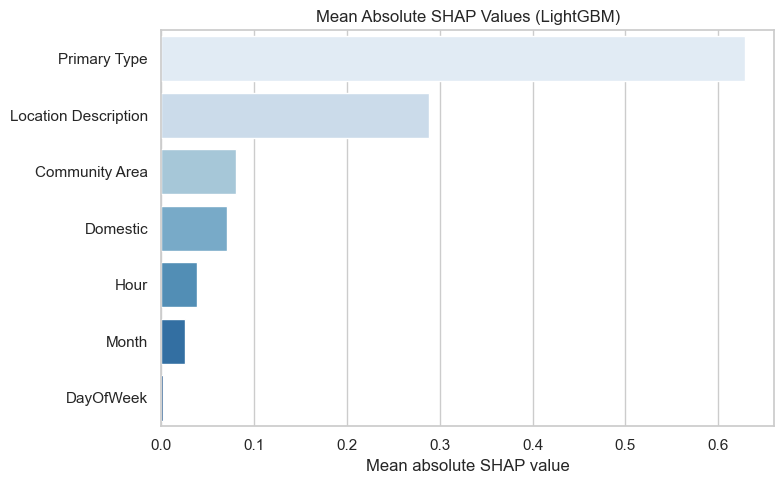

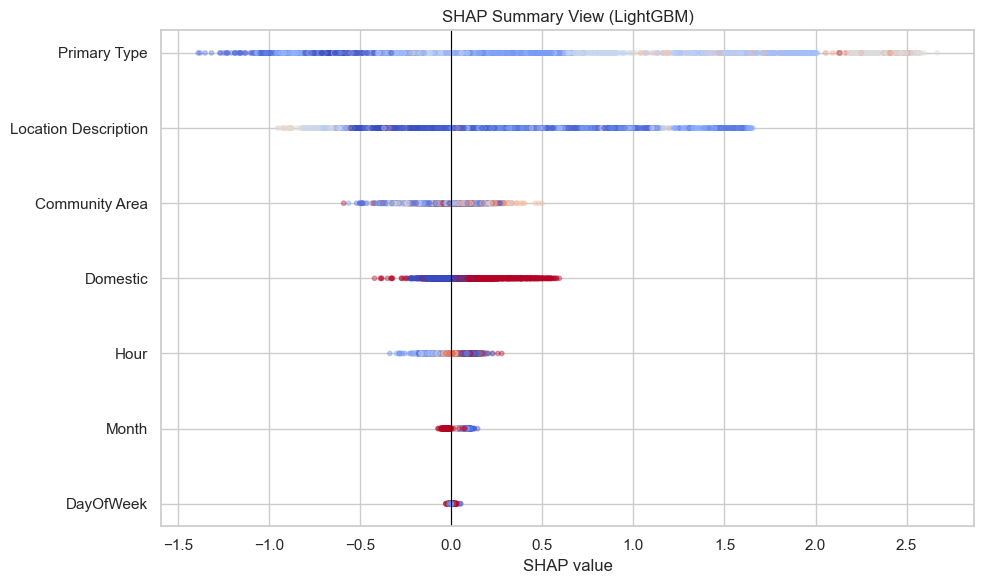

### SHAP Interpretation

For the best-performing final model, the SHAP analysis indicates that **Primary Type**, **Location Description**, and **Community Area** contribute the largest average shifts in predicted arrest probability. This is consistent with the earlier exploratory analysis: arrest outcomes are shaped primarily by offense type and incident setting, with additional signal coming from temporal and community-level context.

The SHAP results reinforce the main modeling conclusion of the project. Arrest prediction in this dataset is not driven by time alone. Instead, the model relies most heavily on the combination of crime category, situational context, and geography, which provides a structured explanation for why boosted models outperform the simpler baseline specification.

In [12]:
shap_importance_path = frame_path('best_model_shap_importance.csv')
shap_sample_path = frame_path('best_model_shap_sample.csv')
shap_values_path = frame_path('best_model_shap_values.npy')
shap_meta = load_metadata().get('sections', {}).get('shap', {})

if (
    shap_importance_path.exists()
    and shap_sample_path.exists()
    and shap_values_path.exists()
    and shap_meta.get('best_model') == best_model_name
):
    shap_importance = load_frame(shap_importance_path)
    shap_sample = load_frame(shap_sample_path)
    shap_feature_values = np.load(shap_values_path)
else:
    best_model = load_model_artifact(best_model_name)
    shap_sample_source = stratified_sample(test_full, min(SHAP_SAMPLE_ROWS, len(test_full)))

    if best_model_name == 'CatBoost':
        shap_sample = prepare_cat_frame(shap_sample_source, BASE_FEATURES)
        shap_pool = Pool(shap_sample, cat_features=cat_feature_indices)
        shap_values = best_model.get_feature_importance(shap_pool, type='ShapValues')
        shap_feature_values = shap_values[:, :-1]

    elif best_model_name == 'LightGBM':
        shap_sample = prepare_lgb_frame(shap_sample_source, BASE_FEATURES)
        shap_values = best_model.predict(shap_sample, pred_contrib=True)
        shap_feature_values = shap_values[:, :-1]

    else:
        raise NotImplementedError(
            f'SHAP section currently supports CatBoost and LightGBM only, got {best_model_name}.'
        )

    shap_importance = pd.DataFrame({
        'Feature': BASE_FEATURES,
        'Mean Absolute SHAP': np.abs(shap_feature_values).mean(axis=0),
    }).sort_values('Mean Absolute SHAP', ascending=False)

    save_frame(shap_importance, shap_importance_path)
    save_frame(shap_sample, shap_sample_path)
    np.save(shap_values_path, shap_feature_values)
    metadata = update_section_metadata('shap', {
        'best_model': best_model_name,
        'importance_file': shap_importance_path.name,
        'sample_file': shap_sample_path.name,
        'values_file': shap_values_path.name,
        'sample_rows': len(shap_sample),
    })

display(shap_importance)

plt.figure(figsize=(8, 5))
sns.barplot(data=shap_importance, x='Mean Absolute SHAP', y='Feature', hue='Feature', palette='Blues', legend=False)
plt.title(f'Mean Absolute SHAP Values ({best_model_name})')
plt.xlabel('Mean absolute SHAP value')
plt.ylabel('')
plt.tight_layout()
plt.show()

order = np.argsort(np.abs(shap_feature_values).mean(axis=0))[::-1]
ordered_features = [BASE_FEATURES[idx] for idx in order]
ordered_values = shap_feature_values[:, order]
ordered_sample = shap_sample[ordered_features]

plt.figure(figsize=(10, 6))
for rank, feature in enumerate(ordered_features[:7]):
    y_vals = ordered_values[:, rank]
    x_vals = ordered_sample[feature]
    if pd.api.types.is_numeric_dtype(x_vals):
        colors = x_vals.astype(float)
    else:
        colors = pd.factorize(x_vals)[0]
    y_jitter = y_vals + np.random.default_rng(RANDOM_STATE + rank).normal(0, 0.01, size=len(y_vals))
    plt.scatter(y_vals, np.full(len(y_vals), len(ordered_features[:7]) - rank), c=colors, cmap='coolwarm', alpha=0.35, s=10)
plt.yticks(range(1, len(ordered_features[:7]) + 1), ordered_features[:7][::-1])
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('SHAP value')
plt.title(f'SHAP Summary View ({best_model_name})')
plt.tight_layout()
plt.show()

top_features = shap_importance['Feature'].head(3).tolist()
shap_md = chr(10).join([
    '### SHAP Interpretation',
    '',
    f"For the best-performing final model, the SHAP analysis indicates that **{top_features[0]}**, **{top_features[1]}**, and **{top_features[2]}** contribute the largest average shifts in predicted arrest probability. This is consistent with the earlier exploratory analysis: arrest outcomes are shaped primarily by offense type and incident setting, with additional signal coming from temporal and community-level context.",
    '',
    'The SHAP results reinforce the main modeling conclusion of the project. Arrest prediction in this dataset is not driven by time alone. Instead, the model relies most heavily on the combination of crime category, situational context, and geography, which provides a structured explanation for why boosted models outperform the simpler baseline specification.',
])
display(Markdown(shap_md))
